In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Mount Google Drive agar hasil training tersimpan permanen
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="vEHmH7ySdxecdJ2lZ8hd")
project = rf.workspace("trial-g0z45").project("deteksi-uang-7cqq5-0jdky")
version = project.version(1)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
from ultralytics import YOLO

# ✅ Load model YOLOv8s dengan pretrained weights
# Pretrained = model sudah belajar fitur dasar (tepi, tekstur, bentuk)
# dari ImageNet → tinggal di-fine-tune ke data uang Rupiah kamu
model = YOLO("yolo26s.pt")

results = model.train(
    data="/content/Deteksi-Uang-1/data.yaml", # Path ke konfigurasi dataset
    epochs=50,          # Tambah jadi 50 — lebih optimal untuk 358 gambar
    batch=16,           # Jumlah gambar per iterasi pembaruan bobot
    imgsz=640,          # Resolusi input: 640×640 piksel
    patience=10,        # Stop otomatis kalau 10 epoch tidak ada peningkatan
    save=True,          # Simpan model terbaik (best.pt)
    device=0,           # Gunakan GPU (ganti 'cpu' kalau tidak ada GPU)
    project="/content/drive/MyDrive/rupiah-detection/runs", # Simpan ke Drive
    name="train_v3",    # Nama folder hasil training
    verbose=True        # Tampilkan log tiap epoch
)

print("🎉 Training selesai!")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Deteksi-Uang-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_v3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

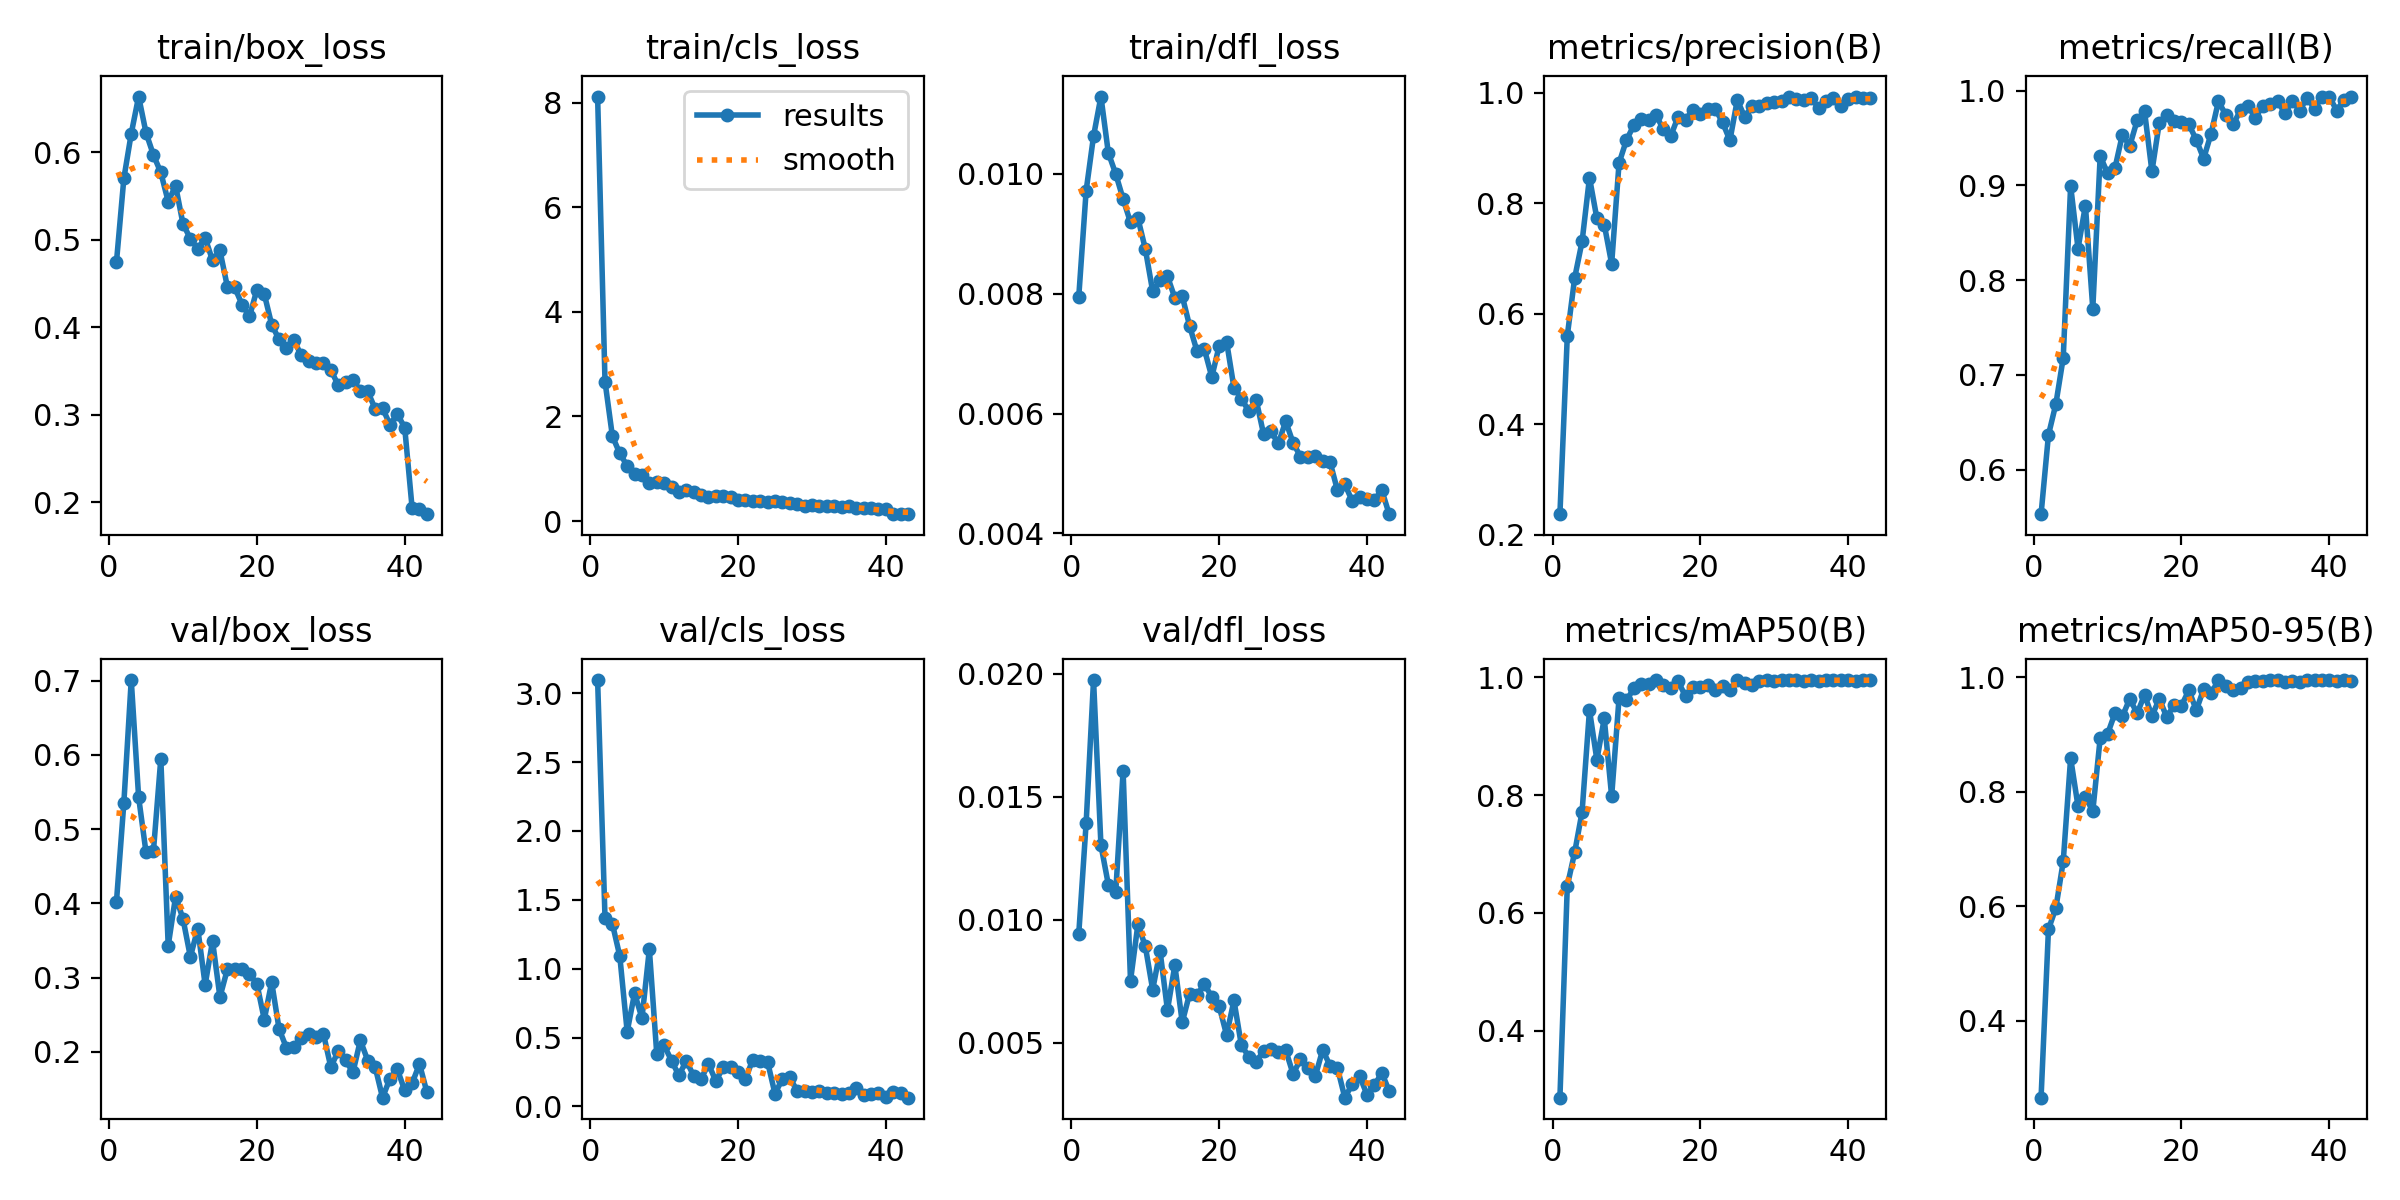

📦 Model terbaik tersimpan di:
/content/drive/MyDrive/rupiah-detection/runs/train_v3/weights/best.pt


In [ ]:
# Tampilkan grafik hasil training (loss, mAP, precision, recall)
from IPython.display import Image, display
import glob

# Tampilkan kurva training
display(Image(
    glob.glob("/content/drive/MyDrive/rupiah-detection/runs/train_v3/results.png")[0]
))

print(f"📦 Model terbaik tersimpan di:")
print(f"/content/drive/MyDrive/rupiah-detection/runs/train_v3/weights/best.pt")

In [ ]:
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# Load model
model = YOLO("/content/drive/MyDrive/rupiah-detection/runs/train_v3/weights/best.pt")

# Cek dulu nama kelas di model kamu
print("📋 Daftar kelas yang dikenali model:")
for idx, name in model.names.items():
    print(f"   ID {idx} → {name}")

📋 Daftar kelas yang dikenali model:
   ID 0 → 1000
   ID 1 → 10000
   ID 2 → 100000
   ID 3 → 2000
   ID 4 → 20000
   ID 5 → 5000
   ID 6 → 50000


In [ ]:
COLOR_MAP = {
    "1000":   (255, 200, 0),    # Biru muda (Format BGR)
    "2000":   (0, 255, 150),    # Hijau mint
    "5000":   (0, 165, 255),    # Oranye
    "10000":  (255, 0, 150),    # Pink/Magenta
    "20000":  (0, 255, 0),      # Hijau terang
    "50000":  (255, 0, 0),      # Biru tua
    "100000": (0, 0, 255),      # Merah
}
DEFAULT_COLOR = (200, 200, 200)


📊 [BERHASIL DIFILTER] Terdeteksi : 1 lembar uang fisik.
💰 Total Nilai Semestinya      : Rp100,000



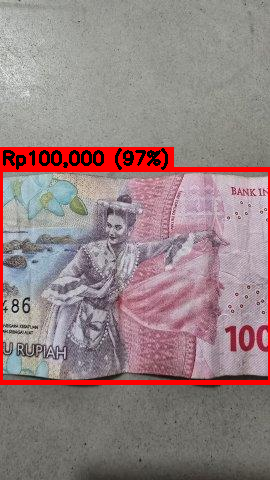

In [ ]:
# 2. Baca gambar yang tadinya bikin double-double
img_path = "/content/drive/MyDrive/rupiah-detection/Contoh/a.100k.jpg"  # ← Sesuaikan path gambarmu
image    = cv2.imread(img_path)

if image is None:
    print("❌ Gambar tidak ditemukan! Cek path-nya ya")
else:
    # Jalankan prediksi (Naikkan conf ke 0.35 biar tebakan super ragu-ragu hilang)
    results = model.predict(source=img_path, conf=0.35, verbose=False)

    # Struktur data untuk mengelompokkan box berdasarkan KELAS NOMINALNYA
    class_boxes = {}

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]
            cls_id   = int(box.cls[0])
            conf     = float(box.conf[0])
            cls_name = model.names[cls_id]

            if cls_name not in class_boxes:
                class_boxes[cls_name] = []
            class_boxes[cls_name].append([x1, y1, x2, y2, conf])

    total_uang     = 0
    jumlah_deteksi = 0

    # ==========================================================
    # LOGIKA INTI PCD: MERGING BOUNDING BOX (PENGGABUNGAN KOTAK)
    # ==========================================================
    for cls_name, boxes in class_boxes.items():
        # Jika dalam 1 kelas (misal Rp1.000) ada beberapa kotak kecil yang kedeteksi
        if len(boxes) > 0:
            # Cari koordinat paling luar (Ekstrem) untuk membungkus semuanya jadi 1 kotak utuh
            all_x1 = [b[0] for b in boxes]
            all_y1 = [b[1] for b in boxes]
            all_x2 = [b[2] for b in boxes]
            all_y2 = [b[3] for b in boxes]
            max_conf = max([b[4] for b in boxes]) # Ambil akurasi tertinggi

            # Kotak raksasa baru hasil gabungan fitur-fitur lokal
            gx1, gy1, gx2, gy2 = min(all_x1), min(all_y1), max(all_x2), max(all_y2)

            color = COLOR_MAP.get(cls_name, DEFAULT_COLOR)

            # Hitung ke total keuangan (Hanya dihitung SATU KALI per kelompok uang)
            try:
                total_uang += int(cls_name)
                jumlah_deteksi += 1
            except ValueError:
                pass

            # Gambar satu kotak besar tunggal pelindung uang
            cv2.rectangle(image, (gx1, gy1), (gx2, gy2), color, 3)

            # Tampilkan Label teks tunggal yang rapi
            label = f"Rp{int(cls_name):,} ({max_conf:.0%})"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(image, (gx1, gy1-th-8), (gx1+tw+4, gy1), color, -1)
            cv2.putText(image, label, (gx1+2, gy1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    # Cetak laporan murni di text output
    print(f"\n📊 [BERHASIL DIFILTER] Terdeteksi : {jumlah_deteksi} lembar uang fisik.")
    print(f"💰 Total Nilai Semestinya      : Rp{total_uang:,}\n")

    # Tampilkan gambar yang sudah bersih dan gak double-double lagi!
    cv2_imshow(image)


📊 [BERHASIL DIFILTER] Terdeteksi : 0 lembar uang fisik.
💰 Total Nilai Semestinya      : Rp0



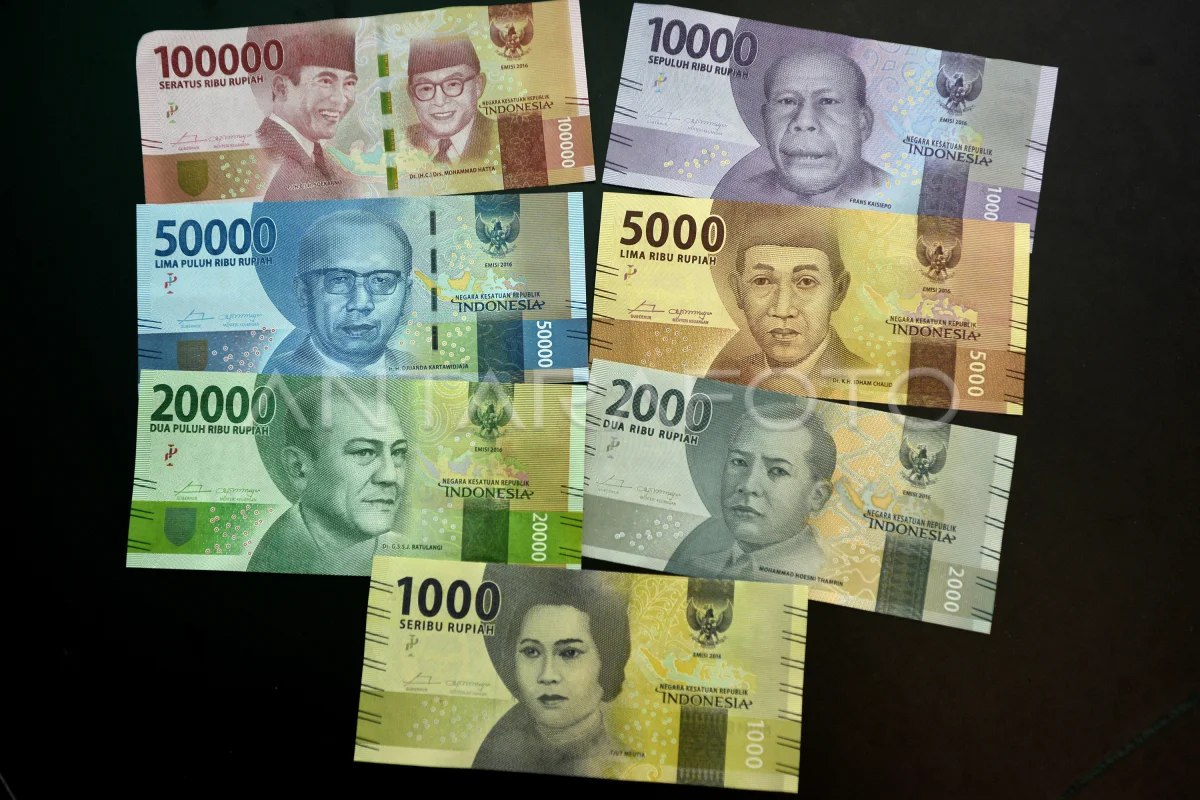

In [ ]:
# 2. Baca gambar yang tadinya bikin double-double
img_path = "/content/tes.jpg"  # ← Sesuaikan path gambarmu
image    = cv2.imread(img_path)

if image is None:
    print("❌ Gambar tidak ditemukan! Cek path-nya ya")
else:
    # Jalankan prediksi (Naikkan conf ke 0.35 biar tebakan super ragu-ragu hilang)
    results = model.predict(source=img_path, conf=0.15, verbose=False)

    # Struktur data untuk mengelompokkan box berdasarkan KELAS NOMINALNYA
    class_boxes = {}

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]
            cls_id   = int(box.cls[0])
            conf     = float(box.conf[0])
            cls_name = model.names[cls_id]

            if cls_name not in class_boxes:
                class_boxes[cls_name] = []
            class_boxes[cls_name].append([x1, y1, x2, y2, conf])

    total_uang     = 0
    jumlah_deteksi = 0

    # ==========================================================
    # LOGIKA INTI PCD: MERGING BOUNDING BOX (PENGGABUNGAN KOTAK)
    # ==========================================================
    for cls_name, boxes in class_boxes.items():
        # Jika dalam 1 kelas (misal Rp1.000) ada beberapa kotak kecil yang kedeteksi
        if len(boxes) > 0:
            # Cari koordinat paling luar (Ekstrem) untuk membungkus semuanya jadi 1 kotak utuh
            all_x1 = [b[0] for b in boxes]
            all_y1 = [b[1] for b in boxes]
            all_x2 = [b[2] for b in boxes]
            all_y2 = [b[3] for b in boxes]
            max_conf = max([b[4] for b in boxes]) # Ambil akurasi tertinggi

            # Kotak raksasa baru hasil gabungan fitur-fitur lokal
            gx1, gy1, gx2, gy2 = min(all_x1), min(all_y1), max(all_x2), max(all_y2)

            color = COLOR_MAP.get(cls_name, DEFAULT_COLOR)

            # Hitung ke total keuangan (Hanya dihitung SATU KALI per kelompok uang)
            try:
                total_uang += int(cls_name)
                jumlah_deteksi += 1
            except ValueError:
                pass

            # Gambar satu kotak besar tunggal pelindung uang
            cv2.rectangle(image, (gx1, gy1), (gx2, gy2), color, 3)

            # Tampilkan Label teks tunggal yang rapi
            label = f"Rp{int(cls_name):,} ({max_conf:.0%})"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(image, (gx1, gy1-th-8), (gx1+tw+4, gy1), color, -1)
            cv2.putText(image, label, (gx1+2, gy1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    # Cetak laporan murni di text output
    print(f"\n📊 [BERHASIL DIFILTER] Terdeteksi : {jumlah_deteksi} lembar uang fisik.")
    print(f"💰 Total Nilai Semestinya      : Rp{total_uang:,}\n")

    # Tampilkan gambar yang sudah bersih dan gak double-double lagi!
    cv2_imshow(image)